# SN 1987A: Hubble–Webb structure comparison

**Scientific question:** Which normalized structures remain spatially similar across HST and JWST?

## Scientific audit protocol

This notebook is one part of a five-notebook case study of SN 1987A. It uses
either compact cutouts from named calibrated MAST FITS products, official NASA
release frames with their processing limits stated, or a peer-reviewed table
whose DOI and units are preserved. The object, coordinate, telescope,
instrument, filter, observing date, and original product name are kept in the
shared manifest. No image is presented as an unexplained illustration.

### Observation versus display

A calibrated FITS pixel and a public colour image are not interchangeable.
The JWST cutouts retain surface brightness in MJy/sr and an error extension.
They can support aperture sums and wavelength-dependent comparisons after
background subtraction. The Hubble release frames were already aligned,
combined, stretched, colour-mapped, compressed, and possibly resampled before
download. They can show where structures appear and can make a useful dated
animation, but their RGB values are not physical flux. The time-lapse notebook
therefore measures only within-frame morphology; calibrated brightness change
is analysed separately from published HST photometry.

An RGB composite is also a mapping, not what a human eye would see. Each
monochromatic infrared channel is assigned a visible colour and stretched to
reveal structure. The notebook records the assignment and shows every input
channel beside the composite. Scientific measurements use the unstretched
arrays, never the rendered RGB pixels. A colour difference is not called a
chemical detection: broad filters mix continuum and emission lines, and a
spectral or narrow-band analysis is needed to identify a constituent.

### Registration, resolution, and uncertainty

Images from different filters are placed on one celestial WCS grid before
pixel-level comparison. The code uses the output sky coordinates rather than
assuming equal array sizes or identical centring. When filters with different
point-spread functions are compared, the sharper images are blurred to a
common approximate resolution. The calculation is repeated across plausible
apertures or smoothing widths so one attractive processing choice cannot carry
the conclusion.

Background is measured away from the remnant. Random aperture uncertainty is
estimated from background scatter or from the published measurement error.
This does not include every calibration, PSF, aperture, or correlated-noise
term, so formal intervals are not promoted to publication-grade errors. For
the literature light curve, residual resampling is used because scatter about
the trend is more realistic than treating the very small tabulated statistical
errors as the only uncertainty.

### Claim boundary

“Validated” means the narrow archive measurement survived the checks named in
this notebook. “Reproduction” means a published table was independently
reanalysed and compared with the paper's conclusion. “Exploration” means the
product is useful for visual or method development but cannot support a
calibrated physical claim. None of these labels means a new supernova,
constituent, compact object, or explosion mechanism has been discovered.

The figures and small tables are saved beside the executed notebook. Each
`result.json` names the evidence figures, reusable artifacts, limitations,
quality checks, and provenance that feed the project dashboard. A null result,
unstable value, or mismatch is retained rather than edited away. This keeps the
repository useful as a learning record and makes the next required observation
or model explicit.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from PIL import Image, ImageDraw
from scipy import ndimage, stats
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
DATA=Path('../../data/sn1987a')
assert DATA.is_dir(), 'Run from the notebook folder inside a complete repository checkout.'
TARGET_RA=83.8666125; TARGET_DEC=-69.2697528

def load_fits(name):
    with fits.open(DATA/name,memmap=False) as h:
        sci=np.asarray(h['SCI'].data,float); err=np.asarray(h['ERR'].data,float) if 'ERR' in h else None
        return sci,err,WCS(h['SCI'].header).celestial,h['SCI'].header.copy()

def reproject_array(array,wcs_in,wcs_out,shape_out,order=1):
    yy,xx=np.indices(shape_out,dtype=float); sky=wcs_out.pixel_to_world(xx,yy); sx,sy=wcs_in.world_to_pixel(sky)
    return ndimage.map_coordinates(array,[sy,sx],order=order,mode='constant',cval=np.nan)

def pixel_scale_arcsec(wcs):
    return float(np.mean(proj_plane_pixel_scales(wcs))*3600)

def stretch(array,low=1,high=99.7,a=8):
    lo,hi=np.nanpercentile(array,[low,high]); z=np.clip((array-lo)/(hi-lo),0,1)
    return np.arcsinh(a*z)/np.arcsinh(a)

Set OBSGEO-B to   -16.348296 from OBSGEO-[XYZ].
Set OBSGEO-H to 1478590370.632 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


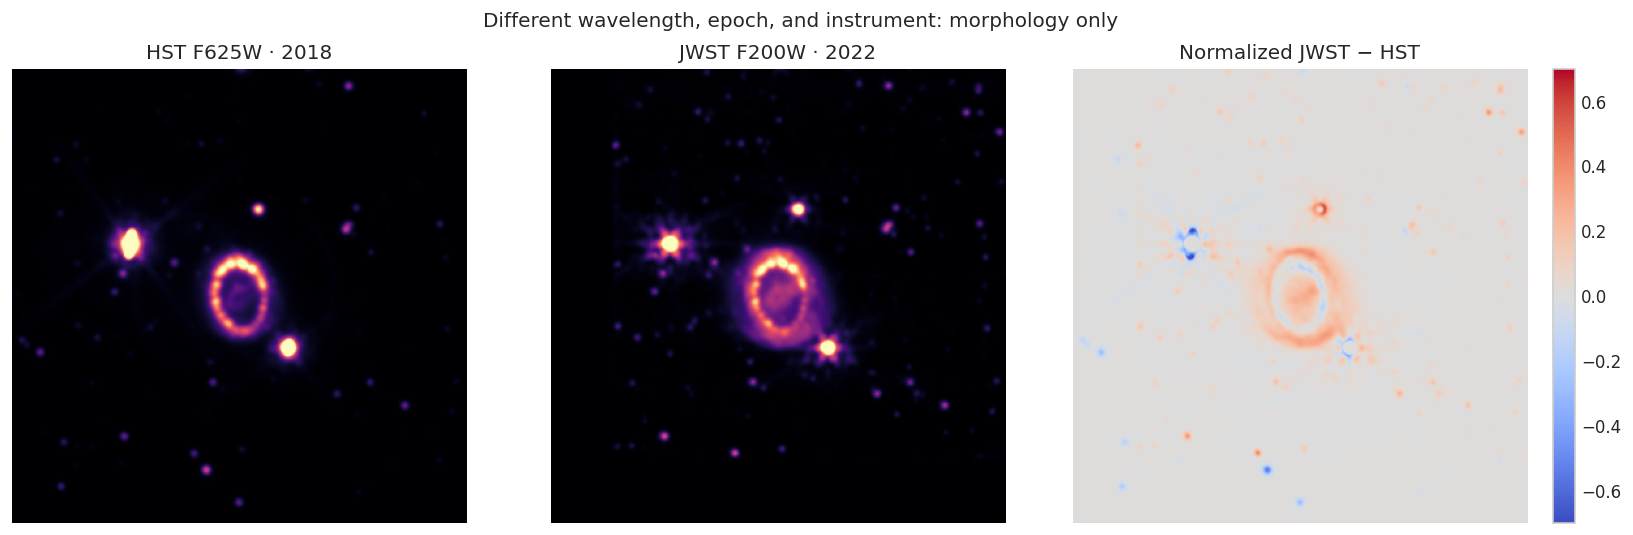

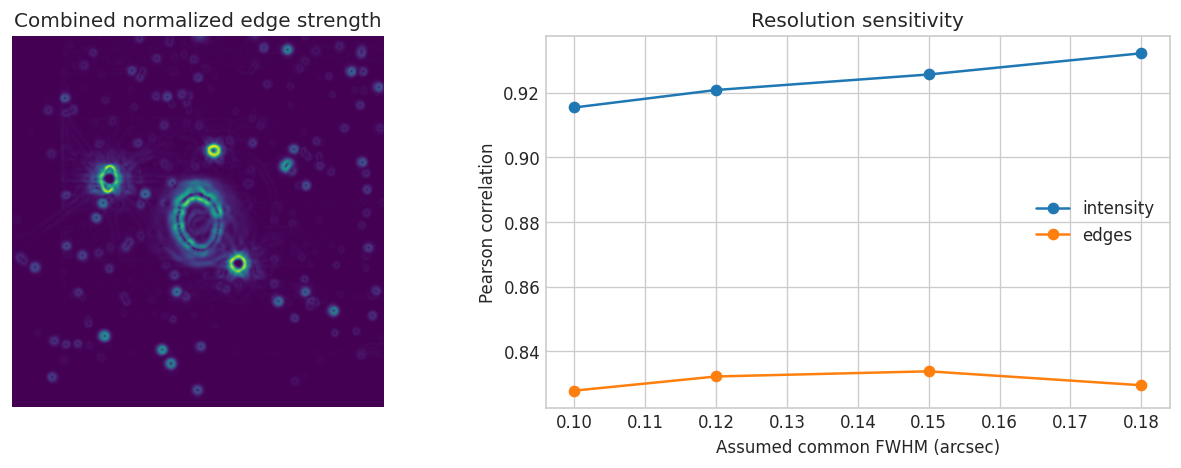

In [2]:
jw,_,wj,hj=load_fits('jwst_f200w_2022_cutout.fits'); hs,_,wh,hh=load_fits('hst_f625w_2018_cutout.fits'); h_on_j=reproject_array(hs,wh,wj,jw.shape); scale=pixel_scale_arcsec(wj); yy,xx=np.indices(jw.shape); from astropy.coordinates import SkyCoord
cx,cy=wj.world_to_pixel(SkyCoord(TARGET_RA,TARGET_DEC,unit='deg')); radius=np.hypot((xx-cx)*scale,(yy-cy)*scale); mask=(radius<1.6)&np.isfinite(h_on_j)&np.isfinite(jw)

def normalized(array):
    bg=(radius>3)&(radius<4.8)&np.isfinite(array); z=array-np.median(array[bg]); p=np.percentile(z[mask],99); return np.clip(np.arcsinh(8*np.maximum(z,0)/p)/np.arcsinh(8),0,1)

rows=[]; examples={}
for common in [.10,.12,.15,.18]:
    sig_h=np.sqrt(max(common**2-.070**2,0))/2.35482/scale; sig_j=np.sqrt(max(common**2-.066**2,0))/2.35482/scale
    hn=normalized(ndimage.gaussian_filter(np.nan_to_num(h_on_j,nan=np.nanmedian(h_on_j)),sig_h)); jn=normalized(ndimage.gaussian_filter(np.nan_to_num(jw,nan=np.nanmedian(jw)),sig_j)); corr=np.corrcoef(hn[mask],jn[mask])[0,1]; edge_h=ndimage.gaussian_gradient_magnitude(hn,1); edge_j=ndimage.gaussian_gradient_magnitude(jn,1); edge_corr=np.corrcoef(edge_h[mask],edge_j[mask])[0,1]; rows.append((common,corr,edge_corr)); examples[common]=(hn,jn,edge_h,edge_j)
stress=pd.DataFrame(rows,columns=['common_fwhm_arcsec','intensity_correlation','edge_correlation']); stress.to_csv('hst_jwst_resolution_stress.csv',index=False); hn,jn,eh,ej=examples[.12]
fig,axes=plt.subplots(1,3,figsize=(14,4.5)); axes[0].imshow(hn,origin='lower',cmap='magma'); axes[0].set_title('HST F625W · 2018'); axes[1].imshow(jn,origin='lower',cmap='magma'); axes[1].set_title('JWST F200W · 2022'); im=axes[2].imshow(jn-hn,origin='lower',cmap='coolwarm',vmin=-.7,vmax=.7); axes[2].set_title('Normalized JWST − HST'); [a.axis('off') for a in axes]; fig.colorbar(im,ax=axes[2],fraction=.046); fig.suptitle('Different wavelength, epoch, and instrument: morphology only'); fig.tight_layout(); fig.savefig('hst_jwst_registered_comparison.png',dpi=180); plt.show()
fig,ax=plt.subplots(1,2,figsize=(11,4)); ax[0].imshow(np.hypot(eh,ej),origin='lower',cmap='viridis'); ax[0].set_title('Combined normalized edge strength'); ax[0].axis('off'); ax[1].plot(stress.common_fwhm_arcsec,stress.intensity_correlation,'o-',label='intensity'); ax[1].plot(stress.common_fwhm_arcsec,stress.edge_correlation,'o-',label='edges'); ax[1].set(xlabel='Assumed common FWHM (arcsec)',ylabel='Pearson correlation',title='Resolution sensitivity'); ax[1].legend(); fig.tight_layout(); fig.savefig('hst_jwst_edge_and_resolution_check.png',dpi=180); plt.show()

In [3]:
nominal=stress.iloc[1]; results=[f'normalized remnant intensity correlation {nominal.intensity_correlation:.3f} at 0.12 arcsec common FWHM',f'edge-map correlation {nominal.edge_correlation:.3f} at the same smoothing',f'correlations explicitly tested from {stress.common_fwhm_arcsec.min():.2f} to {stress.common_fwhm_arcsec.max():.2f} arcsec']
result={'id':'2026-08-01-hst-jwst-sn1987a-comparison','title':'SN 1987A: registered Hubble–Webb structure comparison','archive':'MAST · HST WFC3 + JWST NIRCam','date':'2026-08-01','question':'Which normalized structures remain spatially similar between HST F625W in 2018 and JWST F200W in 2022?','sample_size':int(mask.sum()),'results':results,'validation':'The calibrated cutouts are registered by celestial WCS, normalized separately, blurred to four common resolutions, and compared in intensity and edge space.','notebook':'mast/2026-08-01-hst-jwst-sn1987a-comparison/notebook.ipynb','hero':'mast/2026-08-01-hst-jwst-sn1987a-comparison/hst_jwst_registered_comparison.png','figures':['mast/2026-08-01-hst-jwst-sn1987a-comparison/hst_jwst_registered_comparison.png','mast/2026-08-01-hst-jwst-sn1987a-comparison/hst_jwst_edge_and_resolution_check.png'],'research_level':'Exploration','claim_type':'Cross-instrument morphology','provenance':['HST program 15256 F625W HAP DRC product, 2018-07-08','JWST program 1726 F200W I2D product, 2022-09-02','both compact cutouts preserve WCS and original product names'],'artifacts':['data/sn1987a/hst_f625w_2018_cutout.fits','data/sn1987a/jwst_f200w_2022_cutout.fits','mast/2026-08-01-hst-jwst-sn1987a-comparison/hst_jwst_resolution_stress.csv'],'quality_checks':[{'name':'Celestial WCS registration','status':'pass'},{'name':'Common-resolution stress test','status':'pass'},{'name':'Separate normalization','status':'pass'},{'name':'Cross-band flux comparison','status':'not attempted'}],'limitations':['filters trace different wavelengths and emission processes','observations are four years apart','approximate Gaussian PSFs do not reproduce full instrument PSF wings','correlation is descriptive, not a physical model'],'tags':['HST','JWST','SN 1987A','cross telescope']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n'); print(stress.to_string(index=False))
assert stress.intensity_correlation.between(-1,1).all()

normalized remnant intensity correlation 0.921 at 0.12 arcsec common FWHM
edge-map correlation 0.832 at the same smoothing
correlations explicitly tested from 0.10 to 0.18 arcsec
 common_fwhm_arcsec  intensity_correlation  edge_correlation
               0.10               0.915391          0.827868
               0.12               0.920793          0.832243
               0.15               0.925590          0.833838
               0.18               0.932144          0.829532


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                         name        status
   Celestial WCS registration          pass
Common-resolution stress test          pass
       Separate normalization          pass
   Cross-band flux comparison not attempted


In [5]:
assert Path(Path(result['hero']).name).is_file()

In [6]:
assert all(Path(Path(path).name).is_file() for path in result['figures'])

## Interpretation and references

The comparison asks whether large normalized structures overlap after WCS and
resolution control. It cannot interpret a difference map as temporal change,
because the filters sample optical and infrared emission and the observations
are separated by four years. A publication-grade comparison would forward
model each instrument PSF, match physical band components, propagate WCS
covariance, and use contemporaneous observations.

- HST proposal 15256 dataset: https://doi.org/10.5270/esa-oqihlwz
- JWST program 1726 analysis: https://doi.org/10.1093/mnras/stae1381